# Exploitation de données électorales avec Python
**Evaluation intermédiaire Python pour la data science – mi-semestre 2026**

Ce notebook analyse les résultats du **premier tour de l'élection présidentielle française 2022** à partir des données ouvertes disponibles sur data.gouv.fr.

## Imports et chargement des données

In [ ]:
# Si vous avez executé le requirements.txt, vous pouvez ignorer cette cellule.
# Sinon, executez la pour installer les librairies nécessaires.
!pip install great_tables geopandas cartiflette matplotlib



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
import numpy as np
from great_tables import GT, style, loc, nanoplot_options

# Chargement des données brutes
df = pd.read_csv(
    'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb'
)

print(f"Dimensions du dataframe : {df.shape}")
df.head()

Dimensions du dataframe : (528675, 7)


C:\Users\vicky\AppData\Local\Temp\ipykernel_21288\3730745876.py:9: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
0,01,Ain,1,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3
1,01,Ain,2,L'Abergement-de-Varey,Nathalie,ARTHAUD,2
2,01,Ain,4,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38
3,01,Ain,5,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8
4,01,Ain,6,Ambléon,Nathalie,ARTHAUD,0


In [71]:
# Aperçu des colonnes disponibles
print(df.columns.tolist())
print(df.dtypes)

['code_departement', 'libelle_departement', 'code_commune', 'libelle_commune', 'prenom', 'nom', 'voix']
code_departement       object
libelle_departement    object
code_commune            int64
libelle_commune        object
prenom                 object
nom                    object
voix                    int64
dtype: object


---
## Partie 1 – Explorations générales

### Question 1 – Création / mise à jour des variables `code_commune` et `candidat`

In [72]:
# -----------------------------------------------------------------
# code_commune : concaténation du code département (2 car.) + code
# commune (3 car. avec zéro-remplissage à gauche)
# Exemple : département 92, commune 49  =>  '92049'
# -----------------------------------------------------------------

df['code_departement'] = df['code_departement'].astype(str).str.zfill(2)
df['code_commune']     = (
    df['code_departement']
    + df['code_commune'].astype(str).str.zfill(3)
)

# Vérification : Montrouge doit valoir '92049'
montrouge = df[df['libelle_commune'].str.contains('Montrouge', na=False)]
print("Code commune de Montrouge :", montrouge['code_commune'].unique())

# -----------------------------------------------------------------
# candidat : prénom + espace + nom
# On conserve les lignes abstentions / blancs / nuls
# -----------------------------------------------------------------

df['candidat'] = df['prenom'].fillna('').str.strip() + ' ' + df['nom'].fillna('').str.strip()
df['candidat'] = df['candidat'].str.strip()   # au cas où prenom est vide

print("\nAperçu des candidats disponibles :")
print(df['candidat'].unique()[:20])
df.head(3)

Code commune de Montrouge : ['92049']

Aperçu des candidats disponibles :
['Nathalie ARTHAUD' 'Fabien ROUSSEL' 'Emmanuel MACRON' 'Jean LASSALLE'
 'Marine LE PEN' 'Éric ZEMMOUR' 'Jean-Luc MÉLENCHON' 'Anne HIDALGO'
 'Yannick JADOT' 'Valérie PÉCRESSE' 'Philippe POUTOU'
 'Nicolas DUPONT-AIGNAN' 'abstentions' 'blancs' 'nuls']


,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix,candidat
0,01,Ain,01001,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3,Nathalie ARTHAUD
1,01,Ain,01002,L'Abergement-de-Varey,Nathalie,ARTHAUD,2,Nathalie ARTHAUD
2,01,Ain,01004,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38,Nathalie ARTHAUD


### Question 2 – Nombre de candidats à l'élection

In [73]:
# Les votes non exprimés sont identifiés par des noms particuliers
# (Abstentions, Blancs, Nuls) – on les exclut pour compter les vrais candidats

NON_CANDIDATS = ['Abstentions', 'Blancs', 'Nuls', ' Abstentions', ' Blancs', ' Nuls']

candidats_reels = df[
    ~df['candidat'].isin(NON_CANDIDATS)
    & ~df['nom'].isin(['Abstentions', 'Blancs', 'Nuls'])
    & df['prenom'].notna()
]['candidat'].unique()

candidats = len(candidats_reels)

print(f"En 2022, il y avait {candidats} candidats à l'élection présidentielle.")
print("\nListe des candidats :")
for c in sorted(candidats_reels):
    print(" -", c)

En 2022, il y avait 12 candidats à l'élection présidentielle.

Liste des candidats :
 - Anne HIDALGO
 - Emmanuel MACRON
 - Fabien ROUSSEL
 - Jean LASSALLE
 - Jean-Luc MÉLENCHON
 - Marine LE PEN
 - Nathalie ARTHAUD
 - Nicolas DUPONT-AIGNAN
 - Philippe POUTOU
 - Valérie PÉCRESSE
 - Yannick JADOT
 - Éric ZEMMOUR


### Question 3 – Scores nationaux de chaque candidat

In [74]:
# ------------------------------------------------------------------
# On filtre les votes exprimés (on retire abstentions, blancs, nuls)
# ------------------------------------------------------------------

df_exprimes = df[
    df['prenom'].notna()
    & ~df['nom'].isin(['Abstentions', 'Blancs', 'Nuls'])
].copy()

# Total des votes exprimés
total_exprimes = df_exprimes['voix'].sum()

# Agrégation nationale par candidat
scores_national = (
    df_exprimes
    .groupby('candidat', as_index=False)['voix']
    .sum()
    .rename(columns={'voix': 'votes_national'})
)

scores_national['score_national'] = (
    scores_national['votes_national'] / total_exprimes * 100
).round(2)

scores_national = scores_national.sort_values('votes_national', ascending=False).reset_index(drop=True)

scores_national

,candidat,votes_national,score_national
0,Emmanuel MACRON,9783058,27.85
1,Marine LE PEN,8133828,23.15
2,Jean-Luc MÉLENCHON,7712520,21.95
3,Éric ZEMMOUR,2485226,7.07
4,Valérie PÉCRESSE,1679001,4.78
5,Yannick JADOT,1627853,4.63
6,Jean LASSALLE,1101387,3.13
7,Fabien ROUSSEL,802422,2.28
8,Nicolas DUPONT-AIGNAN,725176,2.06
9,Anne HIDALGO,616478,1.75


In [75]:
# ------------------------------------------------------------------
# Mise en forme avec great_tables
# ------------------------------------------------------------------

gt_table = (
    GT(scores_national)
    .tab_header(
        title="Elections – Résultats du premier tour",
        subtitle="📅 10 avril 2022"
    )
    .cols_label(
        candidat       = "Candidat",
        votes_national = "Nombre votes (total)",
        score_national = "Score (% votes exprimés)"
    )
    .fmt_number(columns='votes_national', sep_mark=' ', decimals=0)
    .fmt_number(columns='score_national', decimals=2, pattern="{x}%")
    .cols_align(align='right', columns=['votes_national', 'score_national'])
)

gt_table

GT(_tbl_data=                 candidat  votes_national  score_national
0         Emmanuel MACRON         9783058           27.85
1           Marine LE PEN         8133828           23.15
2      Jean-Luc MÉLENCHON         7712520           21.95
3            Éric ZEMMOUR         2485226            7.07
4        Valérie PÉCRESSE         1679001            4.78
5           Yannick JADOT         1627853            4.63
6           Jean LASSALLE         1101387            3.13
7          Fabien ROUSSEL          802422            2.28
8   Nicolas DUPONT-AIGNAN          725176            2.06
9            Anne HIDALGO          616478            1.75
10        Philippe POUTOU          268904            0.77
11       Nathalie ARTHAUD          197094            0.56, _body=<great_tables._gt_data.Body object at 0x00000211CDE833F0>, _boxhead=Boxhead([ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='votes_national', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre votes (total)', column_align='right', column_width=None), ColInfo(var='score_national', type=<ColInfoTypeEnum.default: 1>, column_label='Score (% votes exprimés)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x00000211C7F93820>, _spanners=Spanners([]), _heading=Heading(title='Elections – Résultats du premier tour', subtitle='📅 10 avril 2022', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x00000211C7A45850>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x00000211C7A45D50>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x00000211DB2015B0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x00000211C7A45A50>, <great_tables._gt_data.FormatInfo object at 0x00000211C7A46350>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border

---
## Partie 2 – Comparaison des scores départementaux aux moyennes nationales

### Question 4 – Scores par département

In [76]:
# Votes exprimés agrégés par département + candidat
votes_dep = (
    df_exprimes
    .groupby(['code_departement', 'candidat'], as_index=False)['voix']
    .sum()
    .rename(columns={'voix': 'votes'})
)

# Total exprimés par département
total_dep = (
    votes_dep
    .groupby('code_departement')['votes']
    .sum()
    .rename('total_dep')
)

votes_dep = votes_dep.merge(total_dep, on='code_departement')
votes_dep['score'] = (votes_dep['votes'] / votes_dep['total_dep'] * 100).round(2)
votes_dep = votes_dep.drop(columns='total_dep')

score_departements = votes_dep.sort_values(
    ['code_departement', 'votes'], ascending=[True, False]
).reset_index(drop=True)

# Vérification : département 11 (Aude)
print("Résultats pour l'Aude (dep 11) :")
score_departements[score_departements['code_departement'] == '11']

Résultats pour l'Aude (dep 11) :


,code_departement,candidat,votes,score
120,11,Marine LE PEN,64027,30.14
121,11,Emmanuel MACRON,43104,20.29
122,11,Jean-Luc MÉLENCHON,42039,19.79
123,11,Éric ZEMMOUR,18434,8.68
124,11,Jean LASSALLE,12382,5.83
125,11,Valérie PÉCRESSE,7350,3.46
126,11,Yannick JADOT,6322,2.98
127,11,Anne HIDALGO,6166,2.90
128,11,Fabien ROUSSEL,5622,2.65
129,11,Nicolas DUPONT-AIGNAN,4206,1.98


### Question 5 – Lien avec le niveau national

In [77]:
# Jointure avec les scores nationaux
score_departements = score_departements.merge(
    scores_national[['candidat', 'votes_national', 'score_national']],
    on='candidat',
    how='left'
).rename(columns={
    'votes': 'votes_departement',
    'score': 'score_departement'
})

# Vérification : département 11 (Aude)
print("Résultats enrichis pour l'Aude (dep 11) :")
score_departements[
    score_departements['code_departement'] == '11'
][['code_departement','candidat','votes_departement','score_departement','votes_national','score_national']].head(3)

Résultats enrichis pour l'Aude (dep 11) :


,code_departement,candidat,votes_departement,score_departement,votes_national,score_national
120,11,Marine LE PEN,64027,30.14,8133828,23.15
121,11,Emmanuel MACRON,43104,20.29,9783058,27.85
122,11,Jean-Luc MÉLENCHON,42039,19.79,7712520,21.95


### Question 6 – Variable de surreprésentation

In [78]:
score_departements['surrepresentation'] = (
    (score_departements['score_departement'] - score_departements['score_national'])
    / score_departements['score_national']
    * 100
).round(2)

# Vérification : Aude (dep 11)
score_departements[score_departements['code_departement'] == '11']

,code_departement,candidat,votes_departement,score_departement,votes_national,score_national,surrepresentation
120,11,Marine LE PEN,64027,30.14,8133828,23.15,30.19
121,11,Emmanuel MACRON,43104,20.29,9783058,27.85,-27.15
122,11,Jean-Luc MÉLENCHON,42039,19.79,7712520,21.95,-9.84
123,11,Éric ZEMMOUR,18434,8.68,2485226,7.07,22.77
124,11,Jean LASSALLE,12382,5.83,1101387,3.13,86.26
125,11,Valérie PÉCRESSE,7350,3.46,1679001,4.78,-27.62
126,11,Yannick JADOT,6322,2.98,1627853,4.63,-35.64
127,11,Anne HIDALGO,6166,2.90,616478,1.75,65.71
128,11,Fabien ROUSSEL,5622,2.65,802422,2.28,16.23
129,11,Nicolas DUPONT-AIGNAN,4206,1.98,725176,2.06,-3.88


### Question 7 – Visualisation des principales surreprésentations par département

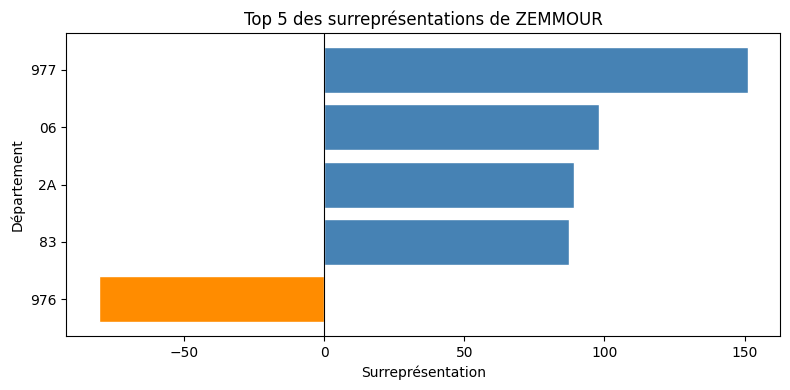

In [79]:
def plot_surrepresentation(candidat_name: str, top_n: int = 5) -> None:
    """
    Affiche un graphique horizontal des top_n surreprésentations
    (en valeur absolue) pour un candidat donné.
    
    Parameters
    ----------
    candidat_name : str
        Nom complet du candidat (ex. 'Éric ZEMMOUR')
    top_n : int
        Nombre de départements à afficher (défaut : 5)
    """
    data = (
        score_departements[score_departements['candidat'] == candidat_name]
        .assign(abs_surrepresentation=lambda x: x['surrepresentation'].abs())
        .nlargest(top_n, 'abs_surrepresentation')   # ← tri par valeur absolue
        .sort_values('surrepresentation')
    )

    # Bleu si positif, orange si négatif (comme le prof)
    colors = ['steelblue' if v >= 0 else 'darkorange'
              for v in data['surrepresentation']]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(
        data['code_departement'],
        data['surrepresentation'],
        color=colors,
        edgecolor='white'
    )
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Surreprésentation')
    ax.set_ylabel('Département')
    nom = candidat_name.split()[-1]
    ax.set_title(f'Top {top_n} des surreprésentations de {nom}')
    plt.tight_layout()
    plt.show()


# Exemple avec Zemmour
plot_surrepresentation('Éric ZEMMOUR', top_n=5)

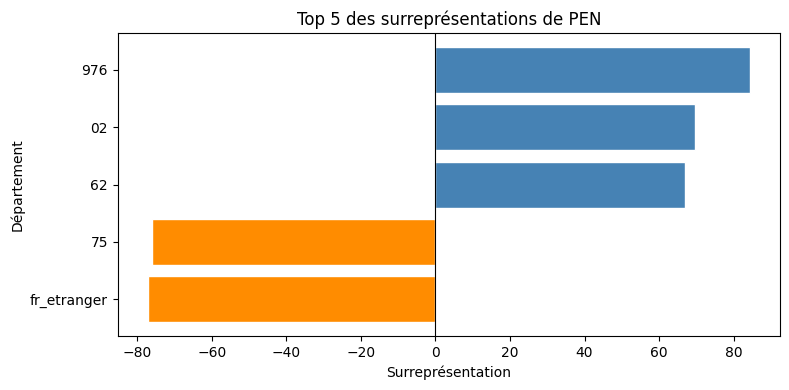

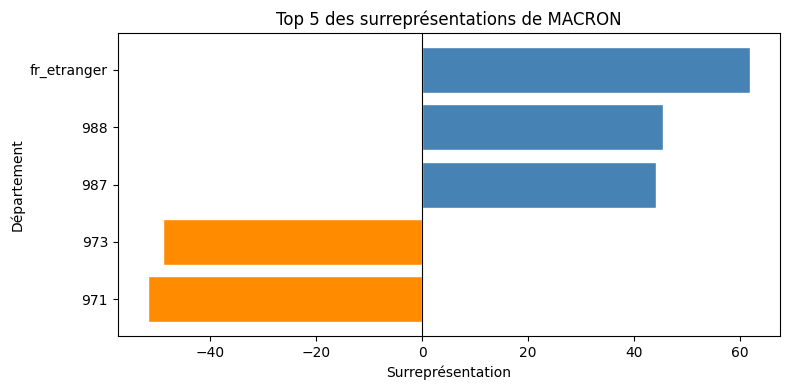

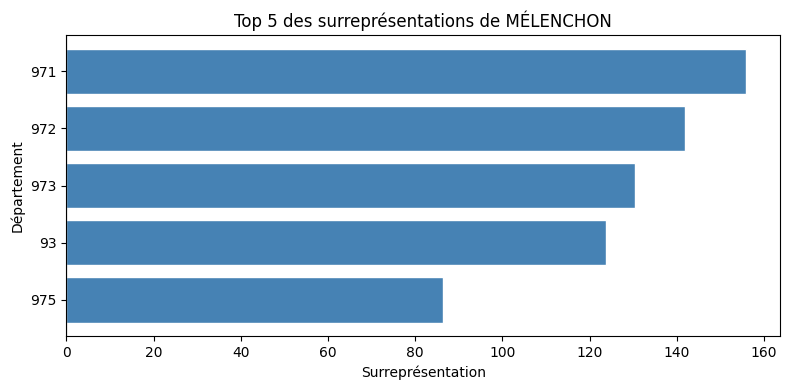

In [80]:
# Autres exemples
plot_surrepresentation('Marine LE PEN',    top_n=5)
plot_surrepresentation('Emmanuel MACRON',  top_n=5)
plot_surrepresentation('Jean-Luc MÉLENCHON', top_n=5)

---
## Partie 3 – Cartographie

### Récupération du fond de carte

In [81]:
from cartiflette import carti_download

departement_borders = carti_download(
    values              = ["France"],
    crs                 = 4326,
    borders             = "DEPARTEMENT",
    vectorfile_format   = "geojson",
    simplification      = 50,
    filter_by           = "FRANCE_ENTIERE_DROM_RAPPROCHES",
    source              = "EXPRESS-COG-CARTO-TERRITOIRE",
    year                = 2022
)

print(departement_borders.columns.tolist())
departement_borders.head(3)

['INSEE_DEP', 'PAYS', 'LIBELLE_DEPARTEMENT', 'POPULATION', 'SOURCE', 'geometry']


,INSEE_DEP,PAYS,LIBELLE_DEPARTEMENT,POPULATION,SOURCE,geometry
0,43,France,Haute-Loire,227570,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((3.89745 45.35699, 3.89691 45.35631, ..."
1,65,France,Hautes-Pyrénées,229567,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"MULTIPOLYGON (((-0.09705 43.5822, -0.09642 43...."
2,29,France,Finistère,915090,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"MULTIPOLYGON (((-3.97907 47.70396, -3.98004 47..."


### Question 8 – Cartographie de la surreprésentation par candidat

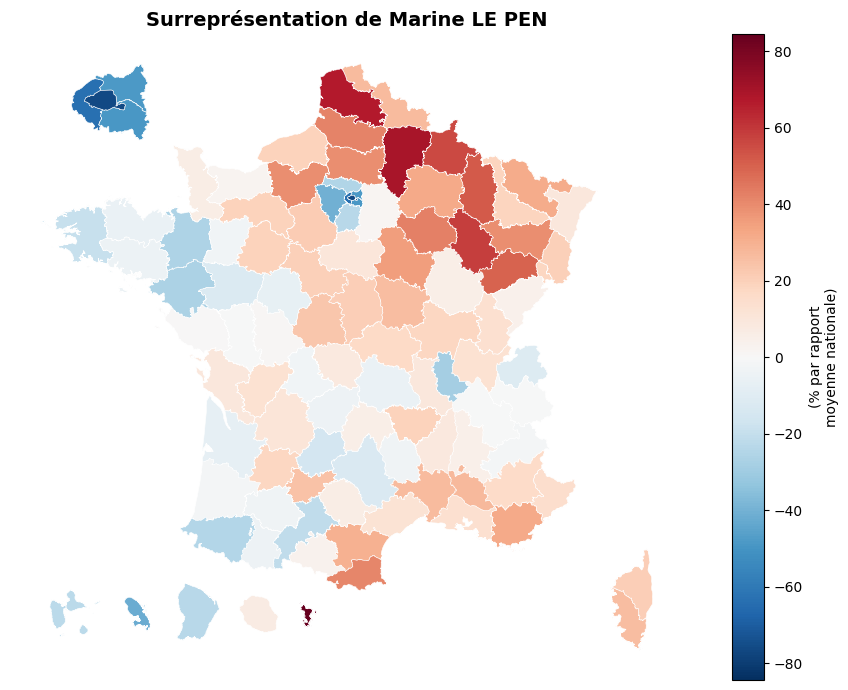

In [82]:
def carte_surrepresentation(candidat_name: str) -> None:
    """
    Affiche une carte choroplèthe de la surreprésentation départementale
    pour un candidat donné.
    
    Parameters
    ----------
    candidat_name : str
        Nom complet du candidat
    """
    # 1. Filtrer les données du candidat
    data_cand = score_departements[
        score_departements['candidat'] == candidat_name
    ][['code_departement', 'surrepresentation']].copy()

    # 2. Identifier la colonne clé dans le GeoDataFrame
    #    (souvent 'DEP' ou 'code' selon cartiflette)
    dep_col = [c for c in departement_borders.columns
               if c.upper() in ('DEP', 'CODE_DEP', 'CODE', 'INSEE_DEP')][0]

    # 3. Jointure spatiale
    gdf = departement_borders.merge(
        data_cand,
        left_on  = dep_col,
        right_on = 'code_departement',
        how      = 'left'
    )

    # 4. Tracé
    vmax = gdf['surrepresentation'].abs().max()
    nom  = candidat_name.split()[-1]

    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    gdf.plot(
        column    = 'surrepresentation',
        ax        = ax,
        cmap      = 'RdBu_r',
        vmin      = -vmax,
        vmax      =  vmax,
        legend    = True,
        edgecolor = 'white',
        linewidth = 0.4,
        legend_kwds = {
            'label'       : '(% par rapport\nmoyenne nationale)',
            'orientation' : 'vertical'
        }
    )
    ax.set_title(f'Surreprésentation de {candidat_name}', fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()


# Test sur Marine Le Pen (reproduit la Figure 2 du sujet)
carte_surrepresentation('Marine LE PEN')

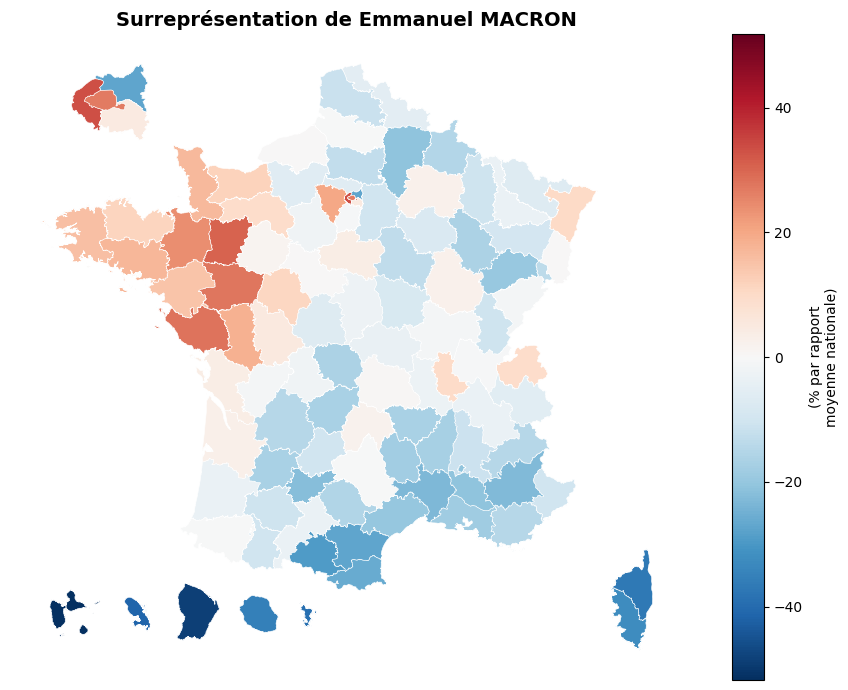

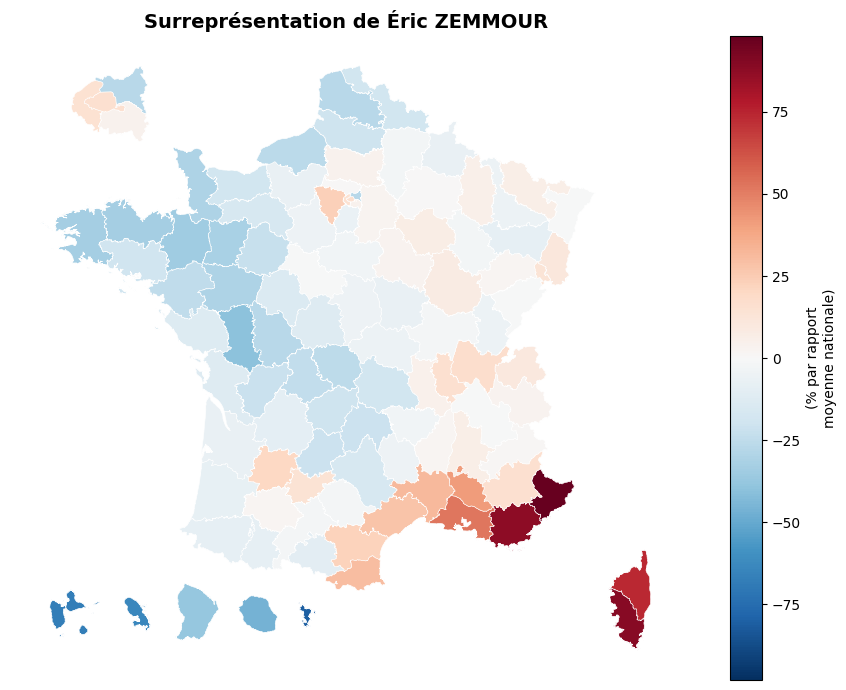

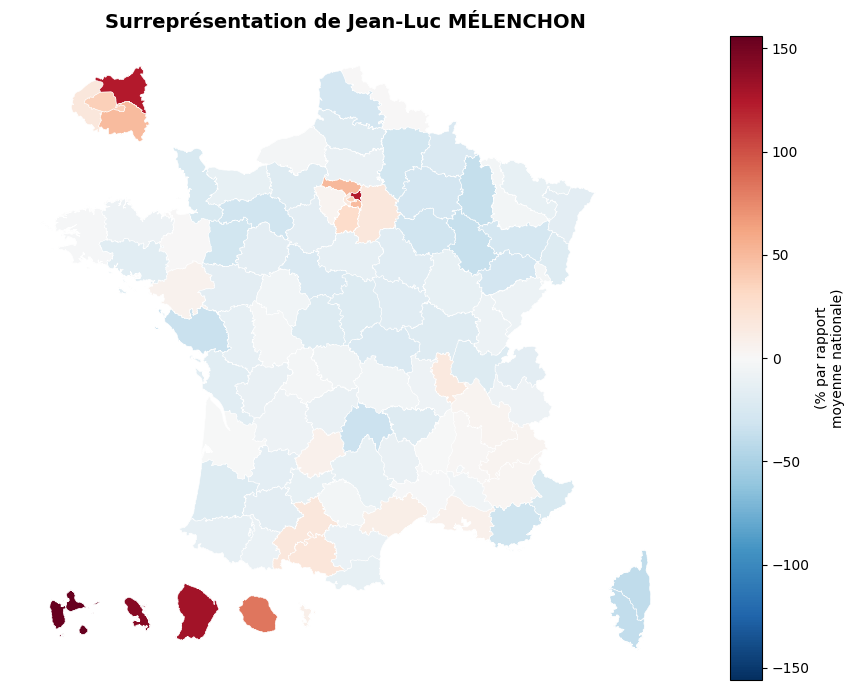

In [83]:
# Cartes pour d'autres candidats
carte_surrepresentation('Emmanuel MACRON')
carte_surrepresentation('Éric ZEMMOUR')
carte_surrepresentation('Jean-Luc MÉLENCHON')

---
## Conclusion

Ce notebook a permis d'explorer les résultats du premier tour de la présidentielle 2022 :

- **Manipulation Pandas** : construction de codes communes, agrégations nationales et départementales.
- **Visualisation** : tableau `great_tables` et graphiques `matplotlib` des surreprésentations.
- **Cartographie** : cartes choroplèthes avec `geopandas` et `cartiflette`.

Les résultats mettent en évidence des territorialités marquées : Marine Le Pen est surreprésentée dans le Nord-Est et le littoral méditerranéen, tandis qu'Emmanuel Macron domine dans les grandes métropoles et leur périphérie.